# Vehicle Sales Data Ingestion & Analytics Pipeline
This notebook contains the complete logic converted from the Vehicle Sales Database Application. It handles data loading, strict cleaning and validation, schema quality checks, and generates business insights directly from the raw CSV data without requiring a database.

### Pipeline Steps:
1. **Environment Setup & Imports**: Load required libraries (pandas, numpy, tabulate).
2. **Data Ingestion & Cleaning**: Load `data/car_prices.csv`, remove missing/placeholder values, validate field ranges, standardize transmission types, validate VINs, parse sale dates, and sort chronologically.
3. **Data Quality Checks**: Identify remaining missing values, count duplicate VINs, and describe the schema.
4. **Sample Data Display**: Generate virtual columns (`Sale Year`, `Sale Month`, `Profit/Loss`) and display chronological samples.
5. **Business Insights**: Compute top makes, profit analysis, weekly and monthly trends, and transmission comparisons.
6. **Visual Analytics**: Render charts for sales volumes, monthly revenue/profit trends, and transmission performance.

### Optional: Install Dependencies
If your environment is missing `tabulate`, `matplotlib`, or `seaborn`, you can uncomment and run the following cell to install them:

In [9]:
# !pip install tabulate matplotlib seaborn

## 1. Environment Setup & Imports
First, we import the necessary libraries. We will use `pandas` for cleaning and data manipulation, `numpy` for missing value handling, and `tabulate` for clean console-style rendering. We will also import `matplotlib` and `seaborn` (wrapped in try-except blocks) for visualization.

In [10]:
import os
import datetime
import pandas as pd
import numpy as np
from tabulate import tabulate

# Suppress setting-with-copy warnings
pd.options.mode.chained_assignment = None

# Try to import visualization libraries
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_VIZ = True
    print("[+] Matplotlib and Seaborn are available for charts.")
except ImportError:
    HAS_VIZ = False
    print("[-] Matplotlib/Seaborn not found. Charts will be skipped but text tables will work.")

print("Pandas version:", pd.__version__)

[+] Matplotlib and Seaborn are available for charts.
Pandas version: 3.0.3


## 2. Ingestion & In-Memory Pipeline Configurations
Define the target dataset path and row limits. By default, the database ingestion capped rows at 50,000 records to ensure fast execution. You can adjust the limit below to process the full dataset (550,000+ records) or keep the 50,000-row cap.

In [11]:
CSV_FILE_PATH = os.path.join("data", "car_prices.csv")
MAX_ROWS = 50000  # Set to None to clean and analyze the FULL dataset (550,000+ rows)

print(f"Source CSV path: {CSV_FILE_PATH}")
print(f"Row Limit (MAX_ROWS): {MAX_ROWS if MAX_ROWS is not None else 'Process Full Dataset'}")

Source CSV path: data\car_prices.csv
Row Limit (MAX_ROWS): 50000


## 3. Date Parser & Data Cleaning Pipeline
We implement the cleaning specifications from the original app:
- **Placeholders**: Drop rows containing empty values or placeholders: `['', '—', 'null', 'nan', 'none', 'n/a', 'na', '-', 'undefined']`.
- **Year**: Must be integer between 1900 and current year + 2.
- **Text Standardisation**: Capitalize string fields (`make`, `model`, `body`, `color`, `interior` in Title Case; `state` and `vin` in Uppercase).
- **Transmission**: Standardize containing 'auto' -> 'automatic', containing 'man' -> 'manual'. Drop other invalid values.
- **VIN**: Length >= 5, alphanumeric only.
- **Condition**: Numeric value between 0.0 and 50.0.
- **Numeric Ranges**: Odometer, MMR, and Selling Price must be >= 0.
- **Sale Date**: Parse complex string timezone formats (`Tue Dec 16 2014 12:30:00 GMT-0800 (PST)`) and generate standardized `saledate` (`YYYY-MM-DD`) and `saleday` (weekday name) fields.
- **Chronological Sort**: Sort records by sale date.

In [12]:
def parse_saledate(date_str):
    """
    Parses timezone-aware strings such as 'Tue Dec 16 2014 12:30:00 GMT-0800 (PST)'
    and standard ISO or slashed date formats.
    """
    if not isinstance(date_str, str) or not date_str:
        return None
    date_str = date_str.strip()
    
    parts = date_str.split()
    if len(parts) >= 5:
        # Extract standard part: "Dec 16 2014 12:30:00"
        clean_str = f"{parts[1]} {parts[2]} {parts[3]} {parts[4]}"
        try:
            return datetime.datetime.strptime(clean_str, "%b %d %Y %H:%M:%S")
        except ValueError:
            pass
            
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d", "%m/%d/%Y %H:%M", "%m/%d/%Y"):
        try:
            return datetime.datetime.strptime(date_str, fmt)
        except ValueError:
            continue
            
    return None

def clean_dataset(path, limit=None):
    if not os.path.exists(path):
        raise FileNotFoundError(f"CSV file not found at {path}. Please check your working directory.")
        
    print(f"[1] Loading CSV data from '{path}'...")
    df = pd.read_csv(path, on_bad_lines='skip')
    initial_count = len(df)
    print(f"    - Loaded {initial_count:,} raw records.")
    
    # 1. Handle missing values and placeholders
    print("\n[2] Checking for missing values and placeholders...")
    missing_placeholders = {'', '—', 'null', 'nan', 'none', 'n/a', 'na', '-', 'undefined'}
    
    valid_mask = pd.Series(True, index=df.index)
    for col in df.columns:
        col_str = df[col].astype(str).str.strip().str.lower()
        is_missing = col_str.isin(missing_placeholders) | col_str.isna() | (col_str == "")
        valid_mask &= ~is_missing
        
    df_clean = df[valid_mask].copy()
    print(f"    - Records after dropping missing values: {len(df_clean):,} (Skipped: {initial_count - len(df_clean):,})")
    
    # 2. Year Validation
    print("\n[3] Validating manufacturing year (1900 to current + 2)...")
    df_clean['year'] = pd.to_numeric(df_clean['year'].astype(str).str.strip(), errors='coerce')
    current_year = datetime.datetime.now().year
    valid_years = (df_clean['year'] >= 1900) & (df_clean['year'] <= current_year + 2)
    df_clean = df_clean[valid_years]
    df_clean['year'] = df_clean['year'].astype(int)
    print(f"    - Records remaining: {len(df_clean):,}")
    
    # 3. Clean and standardise text columns
    print("\n[4] Cleaning and standardising text columns (Make, Model, Body, Colors)...")
    df_clean['make'] = df_clean['make'].astype(str).str.strip().str.title()
    df_clean['model'] = df_clean['model'].astype(str).str.strip().str.title()
    df_clean['trim'] = df_clean['trim'].astype(str).str.strip()
    df_clean['body'] = df_clean['body'].astype(str).str.strip().str.title()
    df_clean['color'] = df_clean['color'].astype(str).str.strip().str.title()
    df_clean['interior'] = df_clean['interior'].astype(str).str.strip().str.title()
    df_clean['seller'] = df_clean['seller'].astype(str).str.strip()
    df_clean['state'] = df_clean['state'].astype(str).str.strip().str.upper()
    
    # 4. Transmission Type Standardisation
    print("\n[5] Standardising transmission types ('automatic' or 'manual')...")
    trans_lower = df_clean['transmission'].astype(str).str.strip().str.lower()
    is_auto = trans_lower.str.contains('auto', na=False)
    is_man = trans_lower.str.contains('man', na=False)
    df_clean.loc[is_auto, 'transmission'] = 'automatic'
    df_clean.loc[is_man, 'transmission'] = 'manual'
    df_clean = df_clean[is_auto | is_man]
    print(f"    - Records remaining: {len(df_clean):,}")
    
    # 5. VIN Validation
    print("\n[6] Validating VIN (length >= 5 & alphanumeric only)...")
    vin_clean = df_clean['vin'].astype(str).str.strip().str.upper()
    valid_vins = (vin_clean.str.len() >= 5) & vin_clean.str.isalnum()
    df_clean['vin'] = vin_clean
    df_clean = df_clean[valid_vins]
    print(f"    - Records remaining: {len(df_clean):,}")
    
    # 6. Condition Validation (0 to 50)
    print("\n[7] Validating condition scores (0 to 50)...")
    df_clean['condition'] = pd.to_numeric(df_clean['condition'].astype(str).str.strip(), errors='coerce')
    df_clean = df_clean[(df_clean['condition'] >= 0) & (df_clean['condition'] <= 50)]
    print(f"    - Records remaining: {len(df_clean):,}")
    
    # 7. Odometer, MMR, and Selling Price Validation
    print("\n[8] Validating Odometer, MMR, and Selling Prices (non-negative)...")
    for col in ['odometer', 'mmr', 'sellingprice']:
        df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.strip(), errors='coerce')
        df_clean = df_clean[df_clean[col] >= 0]
        df_clean[col] = df_clean[col].astype(int)
    print(f"    - Records remaining: {len(df_clean):,}")
    
    # 8. Date Parsing & Weekday Derivation
    print("\n[9] Parsing and cleaning sale dates...")
    parsed_dates = df_clean['saledate'].apply(parse_saledate)
    df_clean = df_clean[parsed_dates.notna()]
    df_clean['saledate_obj'] = parsed_dates[parsed_dates.notna()]
    df_clean['saledate'] = df_clean['saledate_obj'].dt.strftime("%Y-%m-%d")
    df_clean['saleday'] = df_clean['saledate_obj'].dt.strftime("%A")
    print(f"    - Records remaining after date parsing: {len(df_clean):,}")
    
    # 9. Sort Chronologically
    print("\n[10] Sorting records chronologically by sale date...")
    df_clean = df_clean.sort_values(by='saledate_obj').reset_index(drop=True)
    print(f"    - First sale date: {df_clean['saledate'].iloc[0]} ({df_clean['saleday'].iloc[0]})")
    print(f"    - Last sale date: {df_clean['saledate'].iloc[-1]} ({df_clean['saleday'].iloc[-1]})")
    
    # Apply limit
    if limit is not None and len(df_clean) > limit:
        df_clean = df_clean.iloc[:limit].copy()
        print(f"\n[+] Applied record limit: kept first {limit:,} records.")
        
    return df_clean

# Run cleaning pipeline
cleaned_df = clean_dataset(CSV_FILE_PATH, MAX_ROWS)

[1] Loading CSV data from 'data\car_prices.csv'...
    - Loaded 558,837 raw records.

[2] Checking for missing values and placeholders...
    - Records after dropping missing values: 440,393 (Skipped: 118,444)

[3] Validating manufacturing year (1900 to current + 2)...
    - Records remaining: 440,393

[4] Cleaning and standardising text columns (Make, Model, Body, Colors)...

[5] Standardising transmission types ('automatic' or 'manual')...
    - Records remaining: 440,393

[6] Validating VIN (length >= 5 & alphanumeric only)...
    - Records remaining: 440,393

[7] Validating condition scores (0 to 50)...
    - Records remaining: 440,393

[8] Validating Odometer, MMR, and Selling Prices (non-negative)...
    - Records remaining: 440,393

[9] Parsing and cleaning sale dates...
    - Records remaining after date parsing: 440,393

[10] Sorting records chronologically by sale date...
    - First sale date: 2014-01-01 (Wednesday)
    - Last sale date: 2015-07-21 (Tuesday)

[+] Applied rec

## 4. Data Quality & Schema Checks
We run validation scripts to verify that our dataset has zero nulls, identify duplicate VIN counts, and inspect the final schema data types.

In [13]:
print("[1] Verification of NULL/Missing Values:")
null_counts = cleaned_df.isnull().sum()
print(null_counts)

print("\n[2] Check for Duplicate VIN records:")
dup_count = cleaned_df.duplicated(subset=['vin']).sum()
print(f"    - Duplicate VIN records in cleaned dataset: {dup_count:,}")

print("\n[3] Cleaned Dataset Schema:")
types_df = pd.DataFrame(cleaned_df.dtypes, columns=['Data Type']).reset_index()
types_df.columns = ['Field Name', 'Data Type']
print(tabulate(types_df, headers='keys', tablefmt='psql', showindex=False))

[1] Verification of NULL/Missing Values:
year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
saledate_obj    0
saleday         0
dtype: int64

[2] Check for Duplicate VIN records:
    - Duplicate VIN records in cleaned dataset: 122

[3] Cleaned Dataset Schema:
+--------------+----------------+
| Field Name   | Data Type      |
|--------------+----------------|
| year         | int64          |
| make         | str            |
| model        | str            |
| trim         | str            |
| body         | str            |
| transmission | str            |
| vin          | str            |
| state        | str            |
| condition    | float64        |
| odometer     | int64          |
| color        | str            |
| interior     | str       

## 5. Adding Derived/Virtual Columns & Row Samples
Following the SQL database design, we dynamically generate 3 virtual columns:
1. **Sale Year**: The calendar year the vehicle was sold (`YEAR(saledate)`).
2. **Sale Month**: The month name the vehicle was sold (`MONTHNAME(saledate)`).
3. **Profit/Loss**: The difference between the actual selling price and the Manheim Market Report (MMR) value (`sellingprice - mmr`).

Then, we display the first 10 (earliest) and last 10 (latest) records sorted chronologically.

In [14]:
# Generate derived columns
cleaned_df['Sale Year'] = cleaned_df['saledate_obj'].dt.year
cleaned_df['Sale Month'] = cleaned_df['saledate_obj'].dt.strftime('%B')
cleaned_df['Profit/Loss'] = cleaned_df['sellingprice'] - cleaned_df['mmr']

display_cols = [
    'year', 'make', 'model', 'trim', 'body', 'transmission', 
    'vin', 'sellingprice', 'saledate', 'saleday', 'Sale Year', 'Sale Month', 'Profit/Loss'
]

print("--- FIRST 10 RECORDS (Earliest Sold) ---")
print(tabulate(cleaned_df[display_cols].head(10), headers='keys', tablefmt='psql', showindex=False))

print("\n--- LAST 10 RECORDS (Latest Sold) ---")
print(tabulate(cleaned_df[display_cols].tail(10), headers='keys', tablefmt='psql', showindex=False))

--- FIRST 10 RECORDS (Earliest Sold) ---
+--------+-----------+------------------+--------+----------+----------------+-------------------+----------------+------------+-----------+-------------+--------------+---------------+
|   year | make      | model            | trim   | body     | transmission   | vin               |   sellingprice | saledate   | saleday   |   Sale Year | Sale Month   |   Profit/Loss |
|--------+-----------+------------------+--------+----------+----------------+-------------------+----------------+------------+-----------+-------------+--------------+---------------|
|   2006 | Chevrolet | Trailblazer      | LS     | Suv      | automatic      | 1GNDS13S962204461 |           4300 | 2014-01-01 | Wednesday |        2014 | January      |           450 |
|   2003 | Honda     | Accord           | EX     | Sedan    | automatic      | JHMCM56633C021002 |           3100 | 2014-01-01 | Wednesday |        2014 | January      |           925 |
|   2004 | Ford      | F-150 

## 6. Business Insights & Aggregations (Pandas-equivalents of SQL Queries)
We calculate the 5 core business insights that were defined in the database app using pandas aggregations.

In [15]:
# Insight 1: Top 5 Vehicle Makes by Sales Volume
print("1. Top 5 Vehicle Makes by Sales Volume (GROUP BY Make):")
make_volume = cleaned_df['make'].value_counts().reset_index()
make_volume.columns = ['Make', 'Sales Volume']
print(tabulate(make_volume.head(5), headers='keys', tablefmt='psql', showindex=False))

# Insight 2: Top 5 Most Profitable Vehicle Makes (Average Profit/Loss)
print("\n2. Top 5 Most Profitable Vehicle Makes (Average Profit/Loss):")
make_profit = cleaned_df.groupby('make')['Profit/Loss'].mean().reset_index()
make_profit.columns = ['Make', 'Avg Profit/Loss']
make_profit = make_profit.sort_values(by='Avg Profit/Loss', ascending=False)
make_profit['Avg Profit/Loss ($)'] = make_profit['Avg Profit/Loss'].map(lambda x: f"${x:,.2f}")
print(tabulate(make_profit[['Make', 'Avg Profit/Loss ($)']].head(5), headers='keys', tablefmt='psql', showindex=False))

# Insight 3: Weekly Sales Volume and Profit Trend
print("\n3. Weekly Sales Volume and Profit Trend:")
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cleaned_df['saleday'] = pd.Categorical(cleaned_df['saleday'], categories=weekday_order, ordered=True)
weekly = cleaned_df.groupby('saleday', observed=False).agg(
    sales_volume=('sellingprice', 'count'),
    total_revenue=('sellingprice', 'sum'),
    total_profit=('Profit/Loss', 'sum')
).reset_index()
weekly.columns = ['Day of Week', 'Sales Volume', 'Total Revenue', 'Total Profit/Loss']
weekly['Total Revenue'] = weekly['Total Revenue'].map(lambda x: f"${x:,.2f}")
weekly['Total Profit/Loss'] = weekly['Total Profit/Loss'].map(lambda x: f"${x:,.2f}")
print(tabulate(weekly, headers='keys', tablefmt='psql', showindex=False))

# Insight 4: Monthly Sales Volume and Profit Trend
print("\n4. Monthly Sales Volume and Profit Trend (Sorted Chronologically):")
cleaned_df['saledate_month_period'] = cleaned_df['saledate_obj'].dt.to_period('M')
monthly = cleaned_df.groupby('saledate_month_period').agg(
    year=('Sale Year', 'first'),
    month=('Sale Month', 'first'),
    sales_volume=('sellingprice', 'count'),
    total_revenue=('sellingprice', 'sum'),
    total_profit=('Profit/Loss', 'sum')
).reset_index()
monthly.columns = ['Period', 'Year', 'Month', 'Sales Volume', 'Total Revenue', 'Total Profit/Loss']
monthly['Total Revenue'] = monthly['Total Revenue'].map(lambda x: f"${x:,.2f}")
monthly['Total Profit/Loss'] = monthly['Total Profit/Loss'].map(lambda x: f"${x:,.2f}")
print(tabulate(monthly[['Year', 'Month', 'Sales Volume', 'Total Revenue', 'Total Profit/Loss']], headers='keys', tablefmt='psql', showindex=False))

# Insight 5: Transmission Type Comparison
print("\n5. Transmission Type Comparison (Sales Volume, Avg Price, Avg Profit):")
transmission_comp = cleaned_df.groupby('transmission').agg(
    sales_volume=('sellingprice', 'count'),
    avg_selling_price=('sellingprice', 'mean'),
    avg_profit=('Profit/Loss', 'mean')
).reset_index()
transmission_comp.columns = ['Transmission', 'Sales Volume', 'Avg Selling Price', 'Avg Profit/Loss']
transmission_comp['Avg Selling Price'] = transmission_comp['Avg Selling Price'].map(lambda x: f"${x:,.2f}")
transmission_comp['Avg Profit/Loss'] = transmission_comp['Avg Profit/Loss'].map(lambda x: f"${x:,.2f}")
print(tabulate(transmission_comp, headers='keys', tablefmt='psql', showindex=False))

1. Top 5 Vehicle Makes by Sales Volume (GROUP BY Make):
+-----------+----------------+
| Make      |   Sales Volume |
|-----------+----------------|
| Ford      |           7069 |
| Chevrolet |           5848 |
| Nissan    |           4439 |
| Toyota    |           4019 |
| Honda     |           3198 |
+-----------+----------------+

2. Top 5 Most Profitable Vehicle Makes (Average Profit/Loss):
+----------+-----------------------+
| Make     | Avg Profit/Loss ($)   |
|----------+-----------------------|
| Hummer   | $187.14               |
| Plymouth | $50.00                |
| Acura    | $11.34                |
| Smart    | $-18.52               |
| Honda    | $-22.94               |
+----------+-----------------------+

3. Weekly Sales Volume and Profit Trend:
+---------------+----------------+-----------------+---------------------+
| Day of Week   |   Sales Volume | Total Revenue   | Total Profit/Loss   |
|---------------+----------------+-----------------+---------------------|
| 

## 7. Data Visualizations (Replacement for Web Dashboard Charts)
We use `matplotlib` and `seaborn` to generate clean, high-quality visual charts for our analysis results if they are installed.

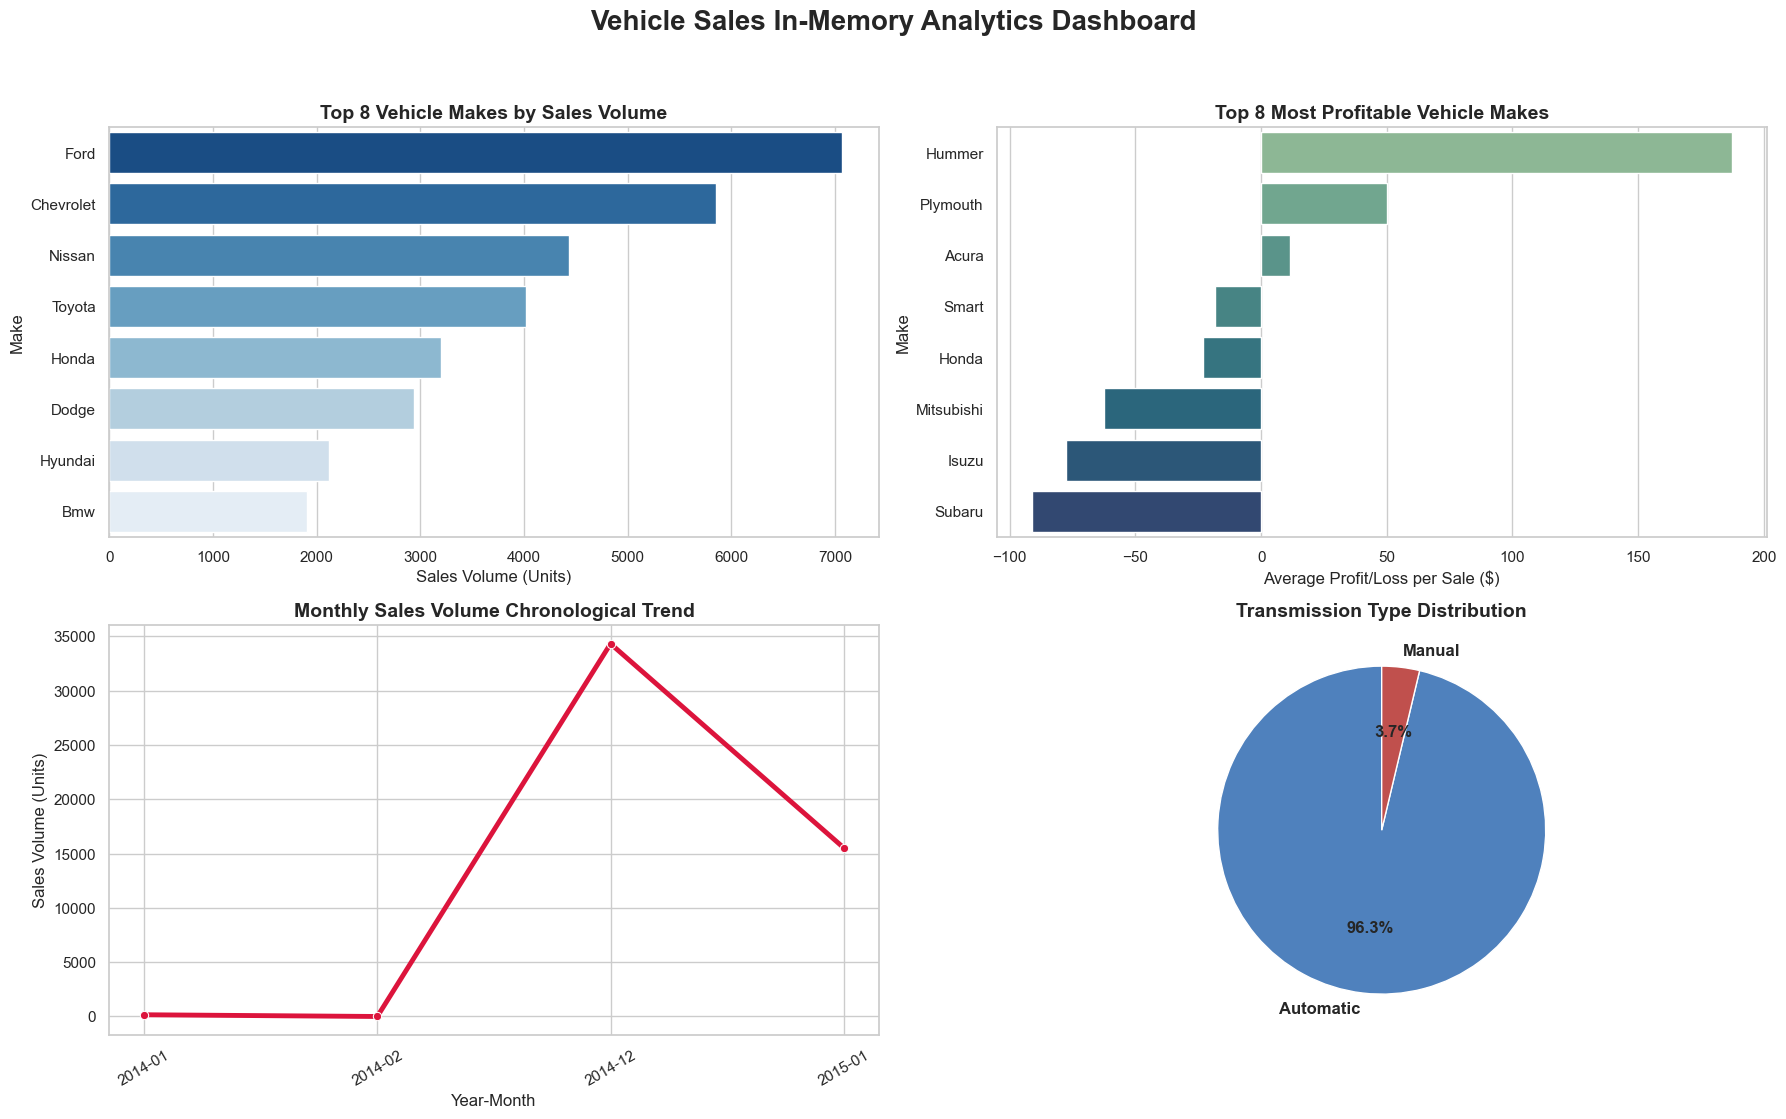

In [16]:
if HAS_VIZ:
    # Set custom premium theme settings
    sns.set_theme(style="whitegrid")
    plt.rcParams['figure.figsize'] = (12, 6)
    plt.rcParams['font.size'] = 11
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Vehicle Sales In-Memory Analytics Dashboard', fontsize=20, weight='bold', y=0.96)
    
    # Plot 1: Top Makes by Sales Volume
    top_makes_data = make_volume.head(8)
    sns.barplot(ax=axes[0,0], data=top_makes_data, x='Sales Volume', y='Make', hue='Make', palette='Blues_r', legend=False)
    axes[0,0].set_title('Top 8 Vehicle Makes by Sales Volume', fontsize=14, weight='bold')
    axes[0,0].set_xlabel('Sales Volume (Units)')
    
    # Plot 2: Average Profit/Loss per Make
    top_profit_data = make_profit.head(8)
    sns.barplot(ax=axes[0,1], data=top_profit_data, x='Avg Profit/Loss', y='Make', hue='Make', palette='crest', legend=False)
    axes[0,1].set_title('Top 8 Most Profitable Vehicle Makes', fontsize=14, weight='bold')
    axes[0,1].set_xlabel('Average Profit/Loss per Sale ($)')
    
    # Plot 3: Monthly Sales Volume Trend
    monthly_plot_df = cleaned_df.groupby('saledate_month_period').size().reset_index(name='Sales Volume')
    monthly_plot_df['Period'] = monthly_plot_df['saledate_month_period'].astype(str)
    sns.lineplot(ax=axes[1,0], data=monthly_plot_df, x='Period', y='Sales Volume', marker='o', color='crimson', linewidth=3.5)
    axes[1,0].set_title('Monthly Sales Volume Chronological Trend', fontsize=14, weight='bold')
    axes[1,0].set_xlabel('Year-Month')
    axes[1,0].set_ylabel('Sales Volume (Units)')
    axes[1,0].tick_params(axis='x', rotation=30)
    
    # Plot 4: Transmission Type Comparison (Sales Volume)
    trans_plot_df = cleaned_df.groupby('transmission').size().reset_index(name='Sales Volume')
    axes[1,1].pie(trans_plot_df['Sales Volume'], labels=trans_plot_df['transmission'].str.title(), autopct='%1.1f%%', 
                 colors=['#4f81bd', '#c0504d'], startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
    axes[1,1].set_title('Transmission Type Distribution', fontsize=14, weight='bold')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()
else:
    print("[-] Matplotlib/Seaborn not installed. Please run: pip install matplotlib seaborn to visualize charts.")